In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pynwb import NWBHDF5IO
from scipy.signal import find_peaks

path = "data/valid/WR+/AO026_20181122_180943.nwb"
THIS_AREA = "wS1"

with NWBHDF5IO(path, "r") as io:
    nwb = io.read()
    tr = nwb.trials.to_dataframe().copy()
    areas = nwb.units["Target_area"].data[:]
    areas = np.array([a.decode() if isinstance(a, (bytes, bytearray)) else a for a in areas])
    unit_mask = (areas == THIS_AREA)

    spike_times = []
    for i in np.where(unit_mask)[0]:
        st = nwb.units["spike_times"][i]
        spike_times.append(np.asarray(st))

print("Number of selected units:", len(spike_times))
print("Example spike train length:", len(spike_times[0]))
print("First 10 spikes:", spike_times[0][:10])
print("Total trials:", len(tr))
print("Stim trials:", tr["whisker_stim"].sum())
print("Catch trials:", tr["no_stim"].sum())

Bin_size = 0.01 # 10 ms bins
AP_Bin_Resolution = 1.0 / Bin_size

duration = float(tr["stop_time"].max())
n_bins = int(np.round(duration * AP_Bin_Resolution))
edges = np.linspace(0.0, n_bins * Bin_size, n_bins + 1)

AP_Bin_Matrx = np.zeros((len(spike_times), n_bins), dtype=np.float32)

for n, st in enumerate(spike_times):
    counts, _ = np.histogram(st, bins=edges)
    AP_Bin_Matrx[n, :] = counts

Mean_Pop_Act = AP_Bin_Matrx.mean(axis=0)

print("Total spikes in AP:", AP_Bin_Matrx.sum())

Number of selected units: 30
Example spike train length: 2727
First 10 spikes: [4.14076667 4.1556     4.47973333 4.48993333 6.58133333 6.61876667
 6.63066667 6.78743333 6.8086     6.86803333]
Total trials: 289
Stim trials: 146
Catch trials: 143
Total spikes in AP: 431640.0


# CREATION MATRICES DES ACTIVITE POUR CHAQUE AMP ET CATCH (BRUIT)

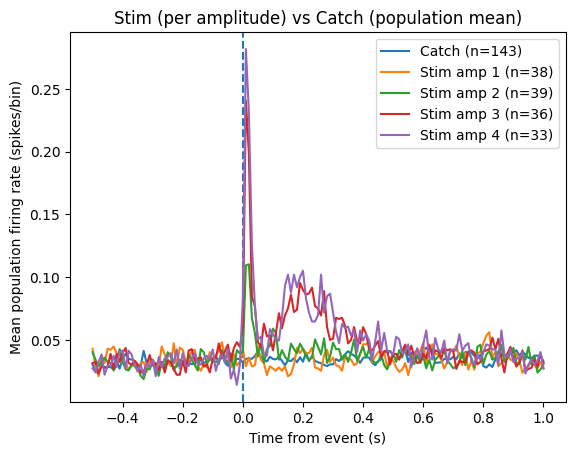

In [21]:
amps_stim = [1,2,3,4]

def event_triggered_matrix(AP_Bin_Matrx, event_times, AP_Bin_Resolution, pre_bins=50, post_bins=100):
    W = pre_bins + post_bins + 1
    mats = []
    for ev in event_times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        pt1, pt2 = pt - pre_bins, pt + post_bins
        if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
            continue
        mats.append(AP_Bin_Matrx[:, pt1:pt2+1].astype(np.float32))  # (n_neurons, W)
    if len(mats) == 0:
        return None, 0
    return np.stack(mats, axis=0), len(mats)  # (n_trials, n_neurons, W)

# event-triggered mean
def event_triggered_mean(AP_Bin_Matrx, event_times, AP_Bin_Resolution, pre_bins=50, post_bins=100):
    W = pre_bins + post_bins + 1
    M = np.zeros((AP_Bin_Matrx.shape[0], W), dtype=np.float32)
    n = 0
    for ev in event_times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        pt1, pt2 = pt - pre_bins, pt + post_bins
        if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
            continue
        M += AP_Bin_Matrx[:, pt1:pt2+1]
        n += 1
    return M / max(n, 1), n

# stim times par amplitude
stim_sel = tr["whisker_stim_time"].notna() & tr["whisker_stim_amplitude"].isin(amps_stim)

Stim_times_by_amp = {
    a: np.sort(tr.loc[stim_sel & (tr["whisker_stim_amplitude"] == a), "whisker_stim_time"].to_numpy())
    for a in amps_stim
}

catch_sel = tr["no_stim"].astype(bool) & tr["no_stim_time"].notna()
Catch_times = np.sort((tr.loc[catch_sel, "no_stim_time"]).to_numpy())

pre_bins, post_bins = 50, 100
time_axis = (np.arange(pre_bins + post_bins + 1) - pre_bins) * Bin_size

CATCH_MTRX, n_catch = event_triggered_mean(AP_Bin_Matrx, Catch_times, AP_Bin_Resolution, pre_bins, post_bins)

plt.figure()
plt.plot(time_axis, CATCH_MTRX.mean(axis=0), label=f"Catch (n={n_catch})")
plt.axvline(0, linestyle="--")

STM_by_amp = {}
for a in amps_stim:
    STM_by_amp[a], n_st = event_triggered_mean(AP_Bin_Matrx, Stim_times_by_amp[a], AP_Bin_Resolution, pre_bins, post_bins)
    plt.plot(time_axis, STM_by_amp[a].mean(axis=0), label=f"Stim amp {a} (n={n_st})")


plt.xlabel("Time from event (s)")
plt.ylabel("Mean population firing rate (spikes/bin)")
plt.title("Stim (per amplitude) vs Catch (population mean)")
plt.legend()
plt.show()

# Matrice de Coding Direction

In [22]:
stim_mask = tr["whisker_stim"].astype(bool).values
catch_mask = tr["no_stim"].astype(bool).values

amps_stim = sorted([
    int(a) for a in pd.unique(tr.loc[stim_mask, "whisker_stim_amplitude"]) if pd.notna(a)
])

Stim_times_by_amp = {}
for a in amps_stim:
    mask_a = stim_mask & (tr["whisker_stim_amplitude"].values == a)
    times_a = tr.loc[mask_a, "whisker_stim_time"].values.astype(float)
    times_a = times_a[~np.isnan(times_a)]
    Stim_times_by_amp[a] = np.sort(times_a)

Catch_times = tr.loc[catch_mask, "no_stim_time"].values.astype(float)
Catch_times = Catch_times[~np.isnan(Catch_times)]
Catch_times = np.sort(Catch_times)

print("Amplitudes :", amps_stim)
for a in amps_stim:
    print(f"amp {a} : {len(Stim_times_by_amp[a])} stimuli")
print("catch :", len(Catch_times))

Amplitudes : [1, 2, 3, 4]
amp 1 : 38 stimuli
amp 2 : 39 stimuli
amp 3 : 36 stimuli
amp 4 : 33 stimuli
catch : 143


In [23]:
win1 = (0, 3)      # premier pic (~0–30 ms)
win2 = (8, 18)    # second pic (~80–180 ms)
pre_baseline = 10


In [24]:
def extract_two_window_matrix(AP, event_time, resolution, win1, win2, pre_baseline):
    pt = int(np.round(event_time * resolution))

    if pt - pre_baseline < 0 or pt + win2[1] >= AP.shape[1]:
        return None

    seg1 = AP[:, pt + win1[0]: pt + win1[1]]
    seg2 = AP[:, pt + win2[0]: pt + win2[1]]

    if seg1.shape[1] == 0 or seg2.shape[1] == 0:
        return None

    mat = np.concatenate([seg1, seg2], axis=1)

    baseline = AP[:, pt - pre_baseline: pt].mean(axis=1, keepdims=True)
    mat = mat - baseline

    return mat


def build_stack(AP, times, resolution, win1, win2, pre_baseline):
    mats = []
    kept_times = []

    for t in times:
        m = extract_two_window_matrix(AP, t, resolution, win1, win2, pre_baseline)
        if m is not None:
            mats.append(m)
            kept_times.append(t)

    if len(mats) == 0:
        return None, np.array([])

    return np.array(mats), np.array(kept_times)


def flatten(mat):
    return mat.reshape(-1).astype(np.float32)


def zscore_vector(v, eps=1e-10):
    v = np.asarray(v, dtype=np.float32)
    mu = np.mean(v)
    sd = np.std(v)
    return (v - mu) / (sd + eps)


def euclidean(v1, v2):
    return np.linalg.norm(v1 - v2)


def cosine(v1, v2):
    denom = (np.linalg.norm(v1) * np.linalg.norm(v2)) + 1e-10
    return np.dot(v1, v2) / denom


def pearson_corr(v1, v2):
    v1z = zscore_vector(v1)
    v2z = zscore_vector(v2)
    return np.mean(v1z * v2z)


def score_stack_against_reference(stack, ref_vector, normalize=True):
    if stack is None or len(stack) == 0:
        return np.array([]), np.array([]), np.array([])

    if normalize:
        ref_used = zscore_vector(ref_vector)
    else:
        ref_used = ref_vector.copy()

    dists = []
    coss = []
    pears = []

    for mat in stack:
        vec = flatten(mat)

        if normalize:
            vec_used = zscore_vector(vec)
        else:
            vec_used = vec

        dists.append(euclidean(vec_used, ref_used))
        coss.append(cosine(vec_used, ref_used))
        pears.append(pearson_corr(vec, ref_vector))

    return np.array(dists), np.array(coss)

def detect_local_extrema(score, t, threshold, mode="high", refractory_s=0.2):
    if mode == "high":
        peak_idx, _ = find_peaks(score, height=threshold)
        candidate_idx = peak_idx
    elif mode == "low":
        peak_idx, _ = find_peaks(-score, height=-threshold)
        candidate_idx = peak_idx
    else:
        raise ValueError("mode doit être 'high' ou 'low'")

    if len(candidate_idx) == 0:
        return np.array([]), np.array([], dtype=int)

    selected = [candidate_idx[0]]

    for idx in candidate_idx[1:]:
        if t[idx] - t[selected[-1]] >= refractory_s:
            selected.append(idx)
        else:
            if mode == "high":
                if score[idx] > score[selected[-1]]:
                    selected[-1] = idx
            else:
                if score[idx] < score[selected[-1]]:
                    selected[-1] = idx

    selected = np.array(selected, dtype=int)
    return t[selected], selected


def match_rate(detected, true_times, tol=0.1):
    if len(true_times) == 0:
        return np.nan

    TP = 0
    for t0 in true_times:
        if np.any(np.abs(detected - t0) < tol):
            TP += 1

    return TP / len(true_times)


def classify_detected_events(detected_times, stim_times_all, tol=0.1):
    stim_detected = []
    spontaneous_detected = []

    for td in detected_times:
        if np.any(np.abs(stim_times_all - td) < tol):
            stim_detected.append(td)
        else:
            spontaneous_detected.append(td)

    return np.array(stim_detected), np.array(spontaneous_detected)


def build_mean_vector_from_detected_times(AP, detected_times, resolution, win1, win2, pre_baseline):
    stack, kept = build_stack(AP, detected_times, resolution, win1, win2, pre_baseline)

    if stack is None or len(stack) == 0:
        return None, None, np.array([])

    mean_mat = stack.mean(axis=0)
    mean_vec = flatten(mean_mat)

    return mean_mat, mean_vec, kept

In [25]:
stim4_stack, _ = build_stack(
    AP_Bin_Matrx,
    Stim_times_by_amp[4],
    AP_Bin_Resolution,
    win1,
    win2,
    pre_baseline
)

catch_stack, _ = build_stack(
    AP_Bin_Matrx,
    Catch_times,
    AP_Bin_Resolution,
    win1,
    win2,
    pre_baseline
)

mean_stim4 = stim4_stack.mean(axis=0)
mean_catch = catch_stack.mean(axis=0)

CD_matrix = mean_stim4 - mean_catch
CD_vector = flatten(CD_matrix)
CD_vector_z = zscore_vector(CD_vector)

print("CD_vector shape :", CD_vector.shape)

CD_vector shape : (390,)


In [26]:
valid_t = []
distances = []
cosines = []

T = AP_Bin_Matrx.shape[1]

for pt in range(pre_baseline, T - win2[1]):
    event_time = pt / AP_Bin_Resolution

    mat = extract_two_window_matrix(
        AP_Bin_Matrx,
        event_time,
        AP_Bin_Resolution,
        win1,
        win2,
        pre_baseline
    )

    if mat is None:
        continue

    vec = flatten(mat)
    vec_z = vec

    distances.append(euclidean(vec_z, CD_vector_z))
    cosines.append(cosine(vec_z, CD_vector_z))

    valid_t.append(pt)

valid_t = np.array(valid_t)
t_cont = valid_t * Bin_size
distances = np.array(distances)
cosines = np.array(cosines)

thr_dist = np.percentile(distances, 5)
thr_cos = np.percentile(cosines, 99)

Nombre total de stimuli : 146


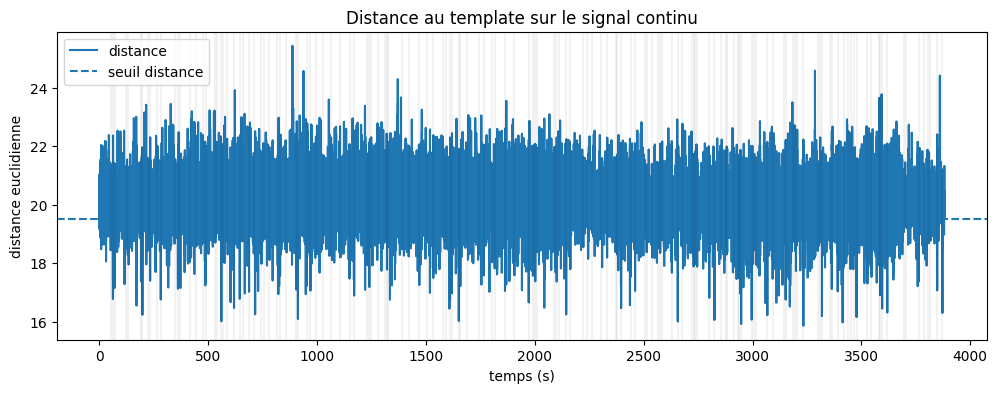

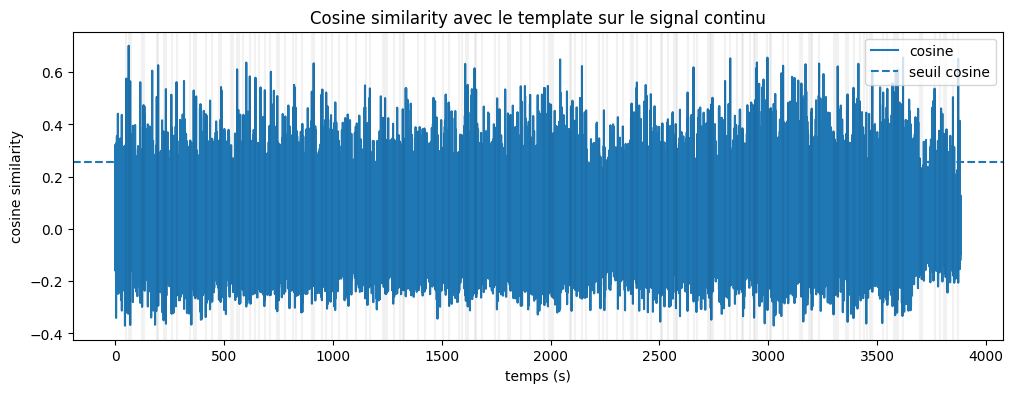

In [27]:
all_stim_times = np.sort(
    np.concatenate([Stim_times_by_amp[a] for a in amps_stim])
)

print("Nombre total de stimuli :", len(all_stim_times))

plt.figure(figsize=(12, 4))
plt.plot(t_cont, distances, label="distance")
plt.axhline(thr_dist, linestyle="--", label="seuil distance")
for ts in all_stim_times:
    plt.axvline(ts, color="k", alpha=0.05)
plt.xlabel("temps (s)")
plt.ylabel("distance euclidienne")
plt.title("Distance au template sur le signal continu")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t_cont, cosines, label="cosine")
plt.axhline(thr_cos, linestyle="--", label="seuil cosine")
for ts in all_stim_times:
    plt.axvline(ts, color="k", alpha=0.05)
plt.xlabel("temps (s)")
plt.ylabel("cosine similarity")
plt.title("Cosine similarity avec le template sur le signal continu")
plt.legend()
plt.show()

In [28]:
refractory_s = 0.4
tol_match = 0.1

detected_cos, detected_cos_idx = detect_local_extrema(
    cosines,
    t_cont,
    threshold=thr_cos,
    mode="high",
    refractory_s=refractory_s
)

detected_dist, detected_dist_idx = detect_local_extrema(
    distances,
    t_cont,
    threshold=thr_dist,
    mode="low",
    refractory_s=refractory_s
)

print("détections cosine :", len(detected_cos))
print("détections distance :", len(detected_dist))

détections cosine : 1808
détections distance : 4310


In [29]:
def match_rate(detected, true_times, tol=0.1):
    TP = 0
    for t in true_times:
        if np.any(np.abs(detected - t) < tol):
            TP += 1
    return TP / len(true_times)


for a in amps_stim:
    print(
        f"amp {a} | dist={match_rate(detected_dist, Stim_times_by_amp[a]):.2f} "
        f"| cos={match_rate(detected_cos, Stim_times_by_amp[a]):.2f} "
    )

amp 1 | dist=0.24 | cos=0.16 
amp 2 | dist=0.56 | cos=0.46 
amp 3 | dist=0.78 | cos=0.75 
amp 4 | dist=1.00 | cos=0.97 


In [30]:
for a in amps_stim:
    rate_cos = match_rate(detected_cos, Stim_times_by_amp[a], tol=tol_match)
    rate_dist = match_rate(detected_dist, Stim_times_by_amp[a], tol=tol_match)

    print(f"amp {a}  cosine={rate_cos:.3f}   distance={rate_dist:.3f}")

stim_detected_cos, spont_detected_cos = classify_detected_events(
    detected_cos,
    all_stim_times,
    tol=tol_match
)

stim_detected_dist, spont_detected_dist = classify_detected_events(
    detected_dist,
    all_stim_times,
    tol=tol_match
)

print()
print("cosine   -> détectés proches d'un stimulus :", len(stim_detected_cos))
print("cosine   -> détectés spontanés :", len(spont_detected_cos))
print("distance -> détectés proches d'un stimulus :", len(stim_detected_dist))
print("distance -> détectés spontanés :", len(spont_detected_dist))

amp 1  cosine=0.158   distance=0.237
amp 2  cosine=0.462   distance=0.564
amp 3  cosine=0.750   distance=0.778
amp 4  cosine=0.970   distance=1.000

cosine   -> détectés proches d'un stimulus : 83
cosine   -> détectés spontanés : 1725
distance -> détectés proches d'un stimulus : 92
distance -> détectés spontanés : 4218


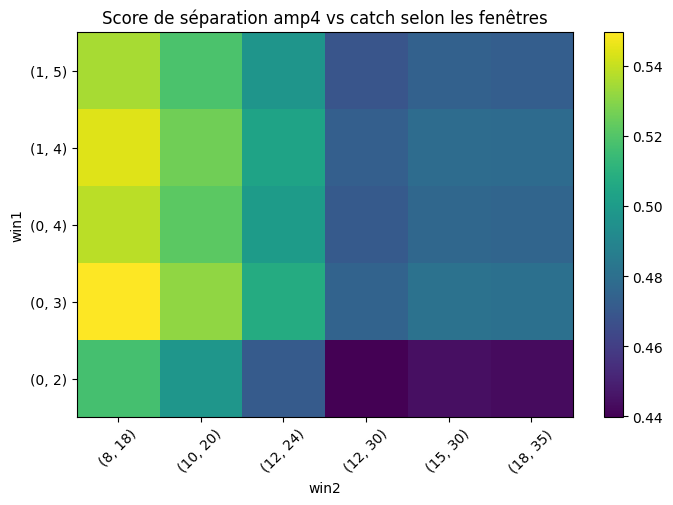

meilleure win1 : (0, 3)
meilleure win2 : (8, 18)


In [31]:
candidate_win1 = [(0,2), (0,3), (0,4), (1,4), (1,5)]
candidate_win2 = [(8,18), (10,20), (12,24), (12,30), (15,30), (18,35)]

grid_score = np.zeros((len(candidate_win1), len(candidate_win2)))

for i, w1 in enumerate(candidate_win1):
    for j, w2 in enumerate(candidate_win2):
        stim_stack_tmp, _ = build_stack(
            AP_Bin_Matrx,
            Stim_times_by_amp[4],
            AP_Bin_Resolution,
            w1,
            w2,
            pre_baseline
        )

        catch_stack_tmp, _ = build_stack(
            AP_Bin_Matrx,
            Catch_times,
            AP_Bin_Resolution,
            w1,
            w2,
            pre_baseline
        )

        if stim_stack_tmp is None or catch_stack_tmp is None:
            grid_score[i, j] = np.nan
            continue

        ref_tmp = flatten(stim_stack_tmp.mean(axis=0) - catch_stack_tmp.mean(axis=0))

        dist_stim, cos_stim = score_stack_against_reference(stim_stack_tmp, ref_tmp)
        dist_catch, cos_catch = score_stack_against_reference(catch_stack_tmp, ref_tmp)

        sep_cos = np.nanmean(cos_stim) - np.nanmean(cos_catch)
        sep_dist = np.nanmean(dist_catch) - np.nanmean(dist_stim)

        grid_score[i, j] = sep_cos

plt.figure(figsize=(8, 5))
plt.imshow(grid_score, aspect="auto", origin="lower")
plt.xticks(np.arange(len(candidate_win2)), [str(w) for w in candidate_win2], rotation=45)
plt.yticks(np.arange(len(candidate_win1)), [str(w) for w in candidate_win1])
plt.xlabel("win2")
plt.ylabel("win1")
plt.title("Score de séparation amp4 vs catch selon les fenêtres")
plt.colorbar()
plt.show()

best_idx = np.unravel_index(np.nanargmax(grid_score), grid_score.shape)
best_win1 = candidate_win1[best_idx[0]]
best_win2 = candidate_win2[best_idx[1]]

print("meilleure win1 :", best_win1)
print("meilleure win2 :", best_win2)

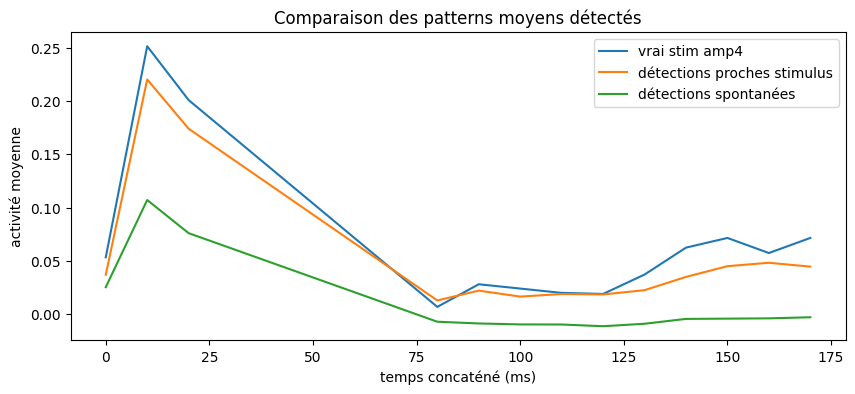

cosine entre spontané détecté et ref : 0.8499371973581357
distance entre spontané détecté et ref : 2.6436605
cosine entre stim détecté et ref : 0.9709903671365634
distance entre stim détecté et ref : 1.0878264


In [32]:
mean_spont_cos_mat, mean_spont_cos_vec, kept_spont_cos = build_mean_vector_from_detected_times(
    AP_Bin_Matrx,
    spont_detected_cos,
    AP_Bin_Resolution,
    win1,
    win2,
    pre_baseline
)

mean_stim_detected_cos_mat, mean_stim_detected_cos_vec, kept_stim_cos = build_mean_vector_from_detected_times(
    AP_Bin_Matrx,
    stim_detected_cos,
    AP_Bin_Resolution,
    win1,
    win2,
    pre_baseline
)

if mean_spont_cos_mat is not None and mean_stim_detected_cos_mat is not None:
    t_concat = np.concatenate([
        np.arange(win1[0], win1[1]),
        np.arange(win2[0], win2[1])
    ]) * Bin_size * 1000

    plt.figure(figsize=(10, 4))
    plt.plot(t_concat, mean_stim4.mean(axis=0), label="vrai stim amp4")
    plt.plot(t_concat, mean_stim_detected_cos_mat.mean(axis=0), label="détections proches stimulus")
    plt.plot(t_concat, mean_spont_cos_mat.mean(axis=0), label="détections spontanées")
    plt.xlabel("temps concaténé (ms)")
    plt.ylabel("activité moyenne")
    plt.title("Comparaison des patterns moyens détectés")
    plt.legend()
    plt.show()

    print("cosine entre spontané détecté et ref :", cosine(mean_spont_cos_vec, CD_vector))
    print("distance entre spontané détecté et ref :", euclidean(mean_spont_cos_vec, CD_vector))

    print("cosine entre stim détecté et ref :", cosine(mean_stim_detected_cos_vec, CD_vector))
    print("distance entre stim détecté et ref :", euclidean(mean_stim_detected_cos_vec, CD_vector))
else:
    print("Pas assez d'événements détectés pour faire cette comparaison.")

In [33]:
all_true_stim_times = np.sort(np.concatenate([Stim_times_by_amp[a] for a in amps_stim]))

true_stim_stack, true_stim_kept = build_stack(
    AP_Bin_Matrx,
    all_true_stim_times,
    AP_Bin_Resolution,
    win1,
    win2,
    pre_baseline
)

spont_cos_stack, spont_cos_kept = build_stack(
    AP_Bin_Matrx,
    spont_detected_cos,
    AP_Bin_Resolution,
    win1,
    win2,
    pre_baseline
)

spont_dist_stack, spont_dist_kept = build_stack(
    AP_Bin_Matrx,
    spont_detected_dist,
    AP_Bin_Resolution,
    win1,
    win2,
    pre_baseline
)

d_true, c_true = score_stack_against_reference(true_stim_stack, CD_vector)
d_spont_cos, c_spont_cos = score_stack_against_reference(spont_cos_stack, CD_vector)
d_spont_dist, c_spont_dist = score_stack_against_reference(spont_dist_stack, CD_vector)

print("Nombre de vrais stimuli gardés :", len(true_stim_kept))
print("Nombre de spontanés cosine gardés :", len(spont_cos_kept))
print("Nombre de spontanés distance gardés :", len(spont_dist_kept))

Nombre de vrais stimuli gardés : 146
Nombre de spontanés cosine gardés : 1725
Nombre de spontanés distance gardés : 4218


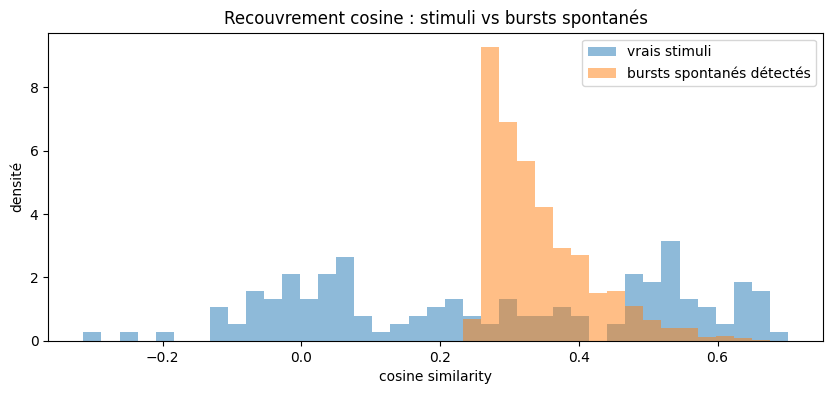

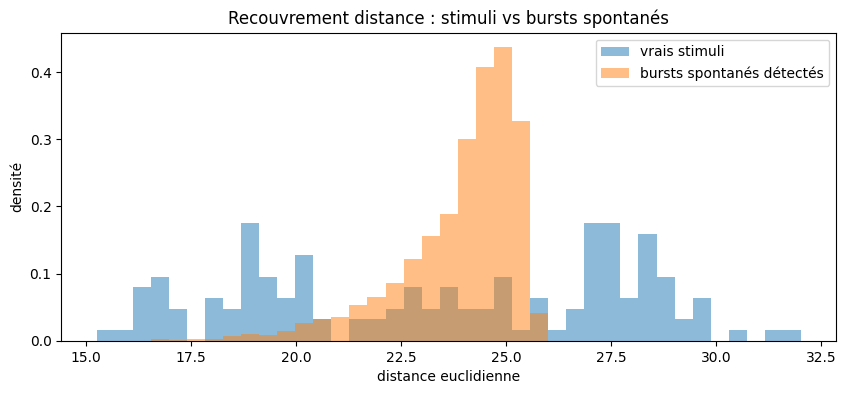

In [34]:
plt.figure(figsize=(10, 4))
bins_cos = np.linspace(
    min(np.nanmin(c_true), np.nanmin(c_spont_cos)),
    max(np.nanmax(c_true), np.nanmax(c_spont_cos)),
    40
)

plt.hist(c_true, bins=bins_cos, alpha=0.5, density=True, label="vrais stimuli")
plt.hist(c_spont_cos, bins=bins_cos, alpha=0.5, density=True, label="bursts spontanés détectés")
plt.xlabel("cosine similarity")
plt.ylabel("densité")
plt.title("Recouvrement cosine : stimuli vs bursts spontanés")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
bins_dist = np.linspace(
    min(np.nanmin(d_true), np.nanmin(d_spont_dist)),
    max(np.nanmax(d_true), np.nanmax(d_spont_dist)),
    40
)

plt.hist(d_true, bins=bins_dist, alpha=0.5, density=True, label="vrais stimuli")
plt.hist(d_spont_dist, bins=bins_dist, alpha=0.5, density=True, label="bursts spontanés détectés")
plt.xlabel("distance euclidienne")
plt.ylabel("densité")
plt.title("Recouvrement distance : stimuli vs bursts spontanés")
plt.legend()
plt.show()

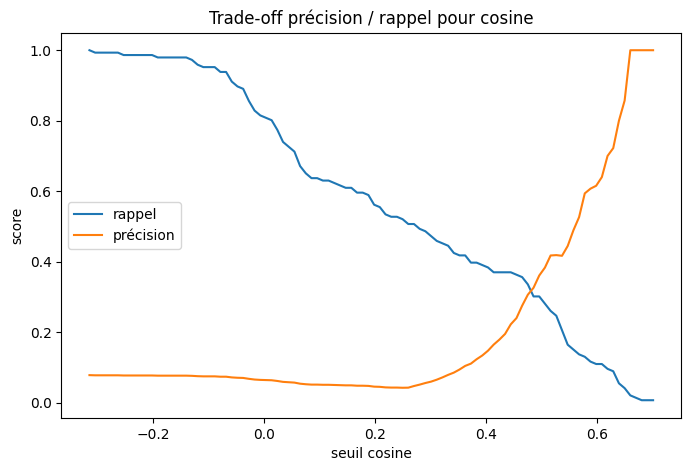

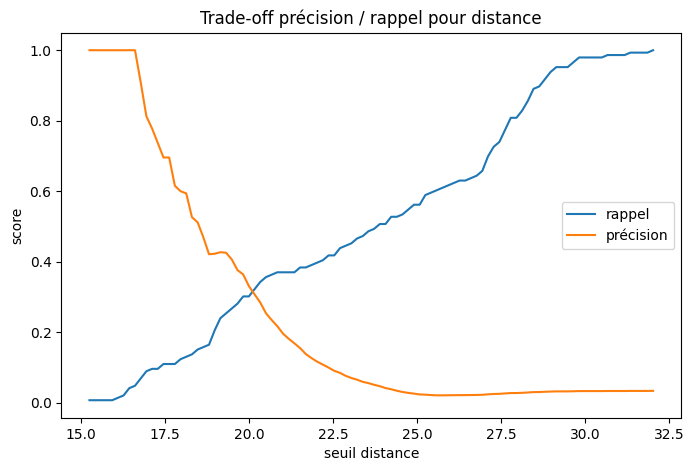

In [35]:
thr_grid_cos = np.linspace(np.nanmin(np.concatenate([c_true, c_spont_cos])),
                           np.nanmax(np.concatenate([c_true, c_spont_cos])), 100)

recall_cos = []
precision_cos = []

for thr in thr_grid_cos:
    tp = np.sum(c_true >= thr)
    fp = np.sum(c_spont_cos >= thr)
    fn = np.sum(c_true < thr)

    rec = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    recall_cos.append(rec)
    precision_cos.append(prec)

plt.figure(figsize=(8, 5))
plt.plot(thr_grid_cos, recall_cos, label="rappel")
plt.plot(thr_grid_cos, precision_cos, label="précision")
plt.xlabel("seuil cosine")
plt.ylabel("score")
plt.title("Trade-off précision / rappel pour cosine")
plt.legend()
plt.show()


thr_grid_dist = np.linspace(np.nanmin(np.concatenate([d_true, d_spont_dist])),
                            np.nanmax(np.concatenate([d_true, d_spont_dist])), 100)

recall_dist = []
precision_dist = []

for thr in thr_grid_dist:
    tp = np.sum(d_true <= thr)
    fp = np.sum(d_spont_dist <= thr)
    fn = np.sum(d_true > thr)

    rec = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    recall_dist.append(rec)
    precision_dist.append(prec)

plt.figure(figsize=(8, 5))
plt.plot(thr_grid_dist, recall_dist, label="rappel")
plt.plot(thr_grid_dist, precision_dist, label="précision")
plt.xlabel("seuil distance")
plt.ylabel("score")
plt.title("Trade-off précision / rappel pour distance")
plt.legend()
plt.show()